In [82]:
import os

os.system(
    "python -m kaggle datasets download -d adamvakar/ericsson-innovation-timeline-patent-evolution -p ."
)

0

In [83]:
import zipfile

with zipfile.ZipFile(
    "ericsson-innovation-timeline-patent-evolution.zip", "r"
) as zip_ref:
    zip_ref.extractall(".")

In [84]:
import pandas as pd

df = pd.read_csv("ericsson_patent_rich_dataset.csv")

df.head()

,patent_id,patent_type,patent_date,patent_title,year,quarter,month,day_of_week,day_of_year,quarter_end,...,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
0,3934093,utility,1976-01-20,Transit exchange for asynchronous data with un...,1976,1,1,1,20,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,1,36
1,3936612,utility,1976-02-03,Control and holding circuit for relay matrices,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,3,36
2,3936781,utility,1976-02-03,Selecting device for crossbar switches,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,2,36
3,3938025,utility,1976-02-10,DC to DC converter for producing two individua...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,5,36
4,3938040,utility,1976-02-10,Apparatus for measuring a signal voltage inclu...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,4,36


In [85]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\Prameel\Desktop\NASSCOM\NASSCOM-Training-\Patent_project
['ericsson-innovation-timeline-patent-evolution.zip', 'Ericsson_Patent_Forecasting_Project.md', 'ericsson_patent_rich_dataset.csv', 'model_results.csv', 'patent.ipynb']


Dataset Overview

In [86]:
df.head()

,patent_id,patent_type,patent_date,patent_title,year,quarter,month,day_of_week,day_of_year,quarter_end,...,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
0,3934093,utility,1976-01-20,Transit exchange for asynchronous data with un...,1976,1,1,1,20,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,1,36
1,3936612,utility,1976-02-03,Control and holding circuit for relay matrices,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,3,36
2,3936781,utility,1976-02-03,Selecting device for crossbar switches,1976,1,2,1,34,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,2,36
3,3938025,utility,1976-02-10,DC to DC converter for producing two individua...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,5,36
4,3938040,utility,1976-02-10,Apparatus for measuring a signal voltage inclu...,1976,1,2,1,41,1976-03-31,...,324.0,347.75,337.375,0.023873,0.074324,10,5.0,0,4,36


Check Dataset Shape

In [87]:
print("Rows and Columns:", df.shape)

Rows and Columns: (30118, 55)


Check Column Names


In [88]:
print(df.columns.tolist())

['patent_id', 'patent_type', 'patent_date', 'patent_title', 'year', 'quarter', 'month', 'day_of_week', 'day_of_year', 'quarter_end', 'title_len_chars', 'title_len_words', 'title_has_number', 'title_has_acronym', 'kw_5g', 'kw_ai_ml', 'kw_cloud_edge', 'kw_security', 'kw_iot', 'kw_network', 'kw_energy', 'kw_antenna', 'kw_data', 'keyword_score', 'is_utility', 'is_design', 'is_other_type', 'tech_era', 'patent_count', 'patent_unique', 'utility_share', 'design_share', 'avg_title_words', 'avg_keyword_score', 'kw_5g_count', 'kw_ai_ml_count', 'kw_cloud_edge_count', 'kw_security_count', 'kw_iot_count', 'kw_network_count', 'kw_energy_count', 'kw_antenna_count', 'kw_data_count', 'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4', 'patent_count_roll4_mean', 'patent_count_roll8_mean', 'patent_count_qoq', 'patent_count_yoy', 'target_patent_count_current', 'target_patent_count_next_quarter', 'years_since_first_patent', 'patent_seq_global', 'year_patent_count']


Dataset Information

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30118 entries, 0 to 30117
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   patent_id                         30118 non-null  str    
 1   patent_type                       30118 non-null  str    
 2   patent_date                       30118 non-null  str    
 3   patent_title                      30118 non-null  str    
 4   year                              30118 non-null  int64  
 5   quarter                           30118 non-null  int64  
 6   month                             30118 non-null  int64  
 7   day_of_week                       30118 non-null  int64  
 8   day_of_year                       30118 non-null  int64  
 9   quarter_end                       30118 non-null  str    
 10  title_len_chars                   30118 non-null  int64  
 11  title_len_words                   30118 non-null  int64  
 12  title_has_numbe

Statistical Summary

In [90]:
df.describe()

,year,quarter,month,day_of_week,day_of_year,title_len_chars,title_len_words,title_has_number,title_has_acronym,kw_5g,...,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
count,30118.000000,30118.000000,30118.000000,30118.0,30118.000000,30118.000000,30118.000000,30118.000000,30118.000000,30118.000000,...,30118.000000,30118.000000,30118.000000,30118.000000,30118.000000,30118.000000,29710.000000,30118.000000,30118.00000,30118.000000
mean,2013.233382,2.514510,6.546185,1.0,183.744638,64.396142,8.820473,0.018594,0.162129,0.007205,...,285.894216,295.571818,288.490475,0.044508,0.126818,302.442924,300.642141,37.233382,15059.50000,1181.884056
std,8.851538,1.101261,3.381182,0.0,103.281235,29.750263,4.383788,0.135087,0.368575,0.084577,...,121.776295,116.262748,115.883764,0.198221,0.331623,119.717223,118.612862,8.851538,8694.46204,455.451109
min,1976.000000,1.000000,1.000000,1.0,1.000000,4.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,2.500000,3.000000,-0.800000,-0.750000,1.000000,1.000000,0.000000,1.00000,12.000000
25%,2008.000000,2.000000,4.000000,1.0,95.000000,44.000000,6.000000,0.000000,0.000000,0.000000,...,197.000000,199.250000,193.000000,-0.067708,-0.054455,211.000000,211.000000,32.000000,7530.25000,797.000000
50%,2015.000000,3.000000,7.000000,1.0,184.000000,60.000000,8.000000,0.000000,0.000000,0.000000,...,324.000000,347.750000,337.375000,0.023873,0.074324,345.000000,345.000000,39.000000,15059.50000,1376.000000
75%,2020.000000,3.000000,9.000000,1.0,271.000000,81.000000,11.000000,0.000000,0.000000,0.000000,...,383.000000,391.000000,377.875000,0.146067,0.220884,399.000000,395.000000,44.000000,22588.75000,1561.000000
max,2025.000000,4.000000,12.000000,1.0,366.000000,268.000000,39.000000,1.000000,1.000000,1.000000,...,525.000000,443.500000,422.375000,3.000000,4.000000,525.000000,525.000000,49.000000,30118.00000,1705.000000


In [91]:
df.describe(include='all')

,patent_id,patent_type,patent_date,patent_title,year,quarter,month,day_of_week,day_of_year,quarter_end,...,patent_count_lag4,patent_count_roll4_mean,patent_count_roll8_mean,patent_count_qoq,patent_count_yoy,target_patent_count_current,target_patent_count_next_quarter,years_since_first_patent,patent_seq_global,year_patent_count
count,30118,30118,30118,30118,30118.000000,30118.000000,30118.000000,30118.0,30118.000000,30118,...,30118.000000,30118.000000,30118.000000,30118.000000,30118.000000,30118.000000,29710.000000,30118.000000,30118.00000,30118.000000
unique,30118,3,2069,25421,NaN,NaN,NaN,NaN,NaN,199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,3934093,utility,2016-02-16,Mobile phone,NaN,NaN,NaN,NaN,NaN,2014-09-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,29694,59,73,NaN,NaN,NaN,NaN,NaN,525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2013.233382,2.514510,6.546185,1.0,183.744638,NaN,...,285.894216,295.571818,288.490475,0.044508,0.126818,302.442924,300.642141,37.233382,15059.50000,1181.884056
std,NaN,NaN,NaN,NaN,8.851538,1.101261,3.381182,0.0,103.281235,NaN,...,121.776295,116.262748,115.883764,0.198221,0.331623,119.717223,118.612862,8.851538,8694.46204,455.451109
min,NaN,NaN,NaN,NaN,1976.000000,1.000000,1.000000,1.0,1.000000,NaN,...,1.000000,2.500000,3.000000,-0.800000,-0.750000,1.000000,1.000000,0.000000,1.00000,12.000000
25%,NaN,NaN,NaN,NaN,2008.000000,2.000000,4.000000,1.0,95.000000,NaN,...,197.000000,199.250000,193.000000,-0.067708,-0.054455,211.000000,211.000000,32.000000,7530.25000,797.000000
50%,NaN,NaN,NaN,NaN,2015.000000,3.000000,7.000000,1.0,184.000000,NaN,...,324.000000,347.750000,337.375000,0.023873,0.074324,345.000000,345.000000,39.000000,15059.50000,1376.000000
75%,NaN,NaN,NaN,NaN,2020.000000,3.000000,9.000000,1.0,271.000000,NaN,...,383.000000,391.000000,377.875000,0.146067,0.220884,399.000000,395.000000,44.000000,22588.75000,1561.000000


Missing values analysis

In [92]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print(missing_values.sort_values(ascending=False))

target_patent_count_next_quarter    408
dtype: int64


Calculate percentage 

In [93]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percent
})

missing_df = missing_df[missing_df['Missing Values'] > 0]

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
target_patent_count_next_quarter,408,1.354672


Visualize Missing Values

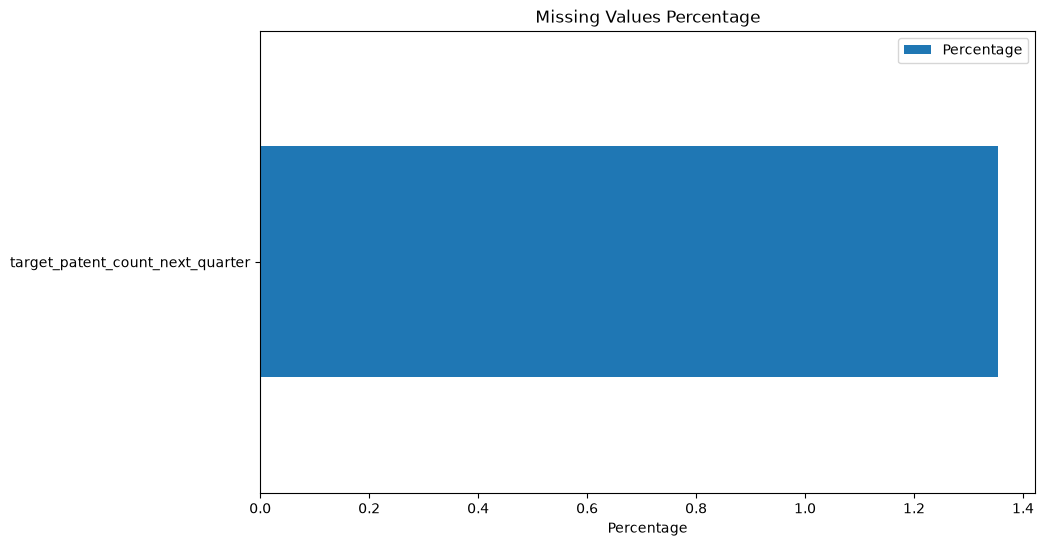

In [94]:
import matplotlib.pyplot as plt

missing_df.sort_values(by='Percentage').plot(
    kind='barh',
    y='Percentage',
    figsize=(10,6)
)

plt.title('Missing Values Percentage')
plt.xlabel('Percentage')
plt.show()

Duplicate Analysis 

In [95]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)


Duplicate Rows: 0


Data Type Inspection

In [96]:
df.dtypes

patent_id                               str
patent_type                             str
patent_date                             str
patent_title                            str
year                                  int64
quarter                               int64
month                                 int64
day_of_week                           int64
day_of_year                           int64
quarter_end                             str
title_len_chars                       int64
title_len_words                       int64
title_has_number                      int64
title_has_acronym                     int64
kw_5g                                 int64
kw_ai_ml                              int64
kw_cloud_edge                         int64
kw_security                           int64
kw_iot                                int64
kw_network                            int64
kw_energy                             int64
kw_antenna                            int64
kw_data                         

In [97]:
#convert datatype of 'patent_date' column to datetime
df['patent_date'] = pd.to_datetime(df['patent_date'])
df['patent_date'].dtype

dtype('<M8[us]')

Basic Target Variable Analysis

In [98]:
df['target_patent_count_next_quarter'].describe()

count    29710.000000
mean       300.642141
std        118.612862
min          1.000000
25%        211.000000
50%        345.000000
75%        395.000000
max        525.000000
Name: target_patent_count_next_quarter, dtype: float64

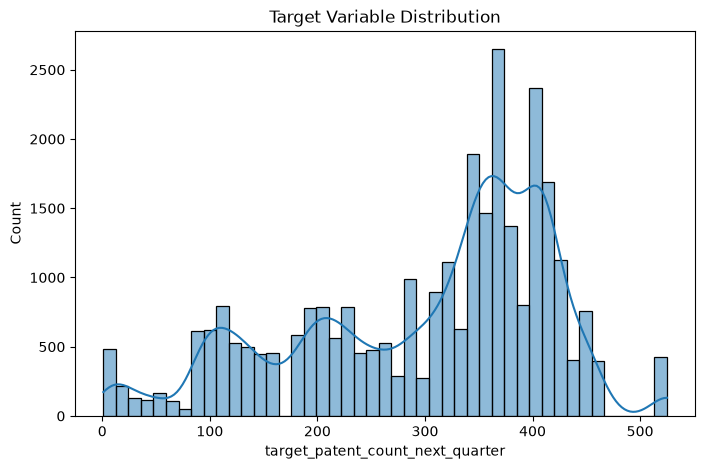

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df['target_patent_count_next_quarter'],
    kde=True
)

plt.title("Target Variable Distribution")
plt.show()

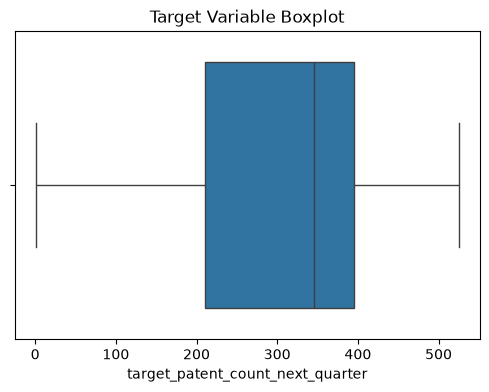

In [100]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=df['target_patent_count_next_quarter']
)

plt.title("Target Variable Boxplot")
plt.show()

In [101]:
df.shape

df.info()

df.isnull().sum().sort_values(ascending=False).head(15)

df.duplicated().sum()

df['target_patent_count_next_quarter'].describe()

<class 'pandas.DataFrame'>
RangeIndex: 30118 entries, 0 to 30117
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   patent_id                         30118 non-null  str           
 1   patent_type                       30118 non-null  str           
 2   patent_date                       30118 non-null  datetime64[us]
 3   patent_title                      30118 non-null  str           
 4   year                              30118 non-null  int64         
 5   quarter                           30118 non-null  int64         
 6   month                             30118 non-null  int64         
 7   day_of_week                       30118 non-null  int64         
 8   day_of_year                       30118 non-null  int64         
 9   quarter_end                       30118 non-null  str           
 10  title_len_chars                   30118 non-null  int64  

count    29710.000000
mean       300.642141
std        118.612862
min          1.000000
25%        211.000000
50%        345.000000
75%        395.000000
max        525.000000
Name: target_patent_count_next_quarter, dtype: float64

We indentified that target_patent_count_next_quarter has missing values i.e. non null count : 29710, total rows = 30118,so, missing rows is 408

In [102]:
df['target_patent_count_next_quarter'].isnull().sum()

408

Why are these values missing?

This target represents the next quarter patent count.

For the last available quarter in the dataset, there is no future quarter available, so the target becomes NaN.

These rows cannot be used for supervised learning.

Remove Missing Target Rows

In [103]:
df = df.dropna(subset=['target_patent_count_next_quarter'])

print(df.shape)

(29710, 55)


Duplicate Check

In [104]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Check Unique Values of Categorical Columns (before encoding lets inspect them)

In [105]:
print(df['patent_type'].value_counts())

patent_type
utility    29289
design       376
reissue       45
Name: count, dtype: int64


In [106]:
print(df['tech_era'].value_counts())

tech_era
smartphone_2010s    13841
modern_2020s         7739
mobile_2000s         5740
legacy_1990s         1954
legacy_pre_1990       436
Name: count, dtype: int64


In [107]:
print(df['quarter_end'].value_counts())

quarter_end
2014-09-30    525
2019-12-31    461
2016-03-31    448
2017-06-30    447
2016-12-31    440
             ... 
1983-06-30      3
1985-06-30      3
1989-12-31      3
1981-06-30      1
1982-03-31      1
Name: count, Length: 198, dtype: int64


EDA Phase 

Patent Activity by year

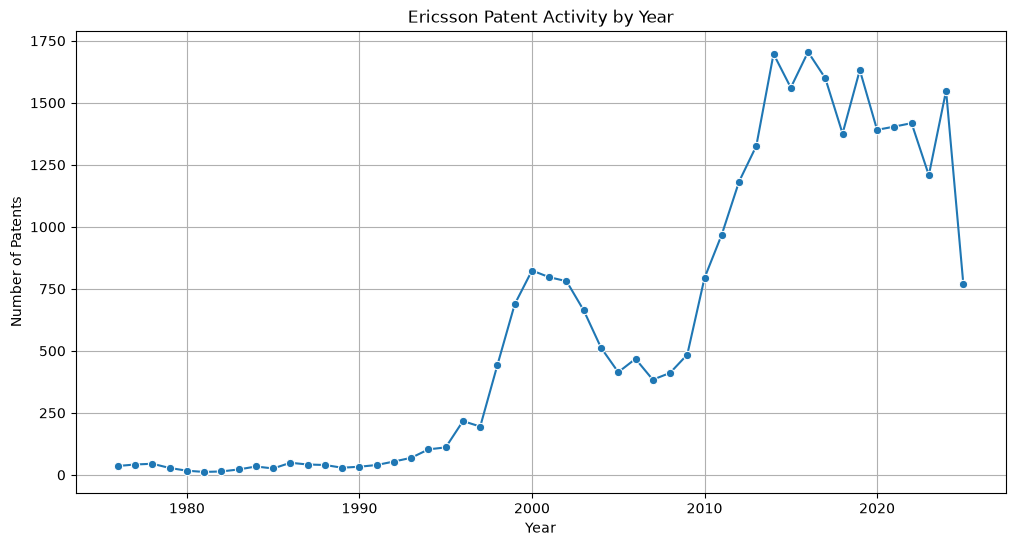

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

year_counts = df.groupby('year')['patent_id'].count()

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker='o'
)

plt.title('Ericsson Patent Activity by Year')
plt.xlabel('Year')
plt.ylabel('Number of Patents')
plt.grid(True)

plt.show()

Patent Activity by Quarter

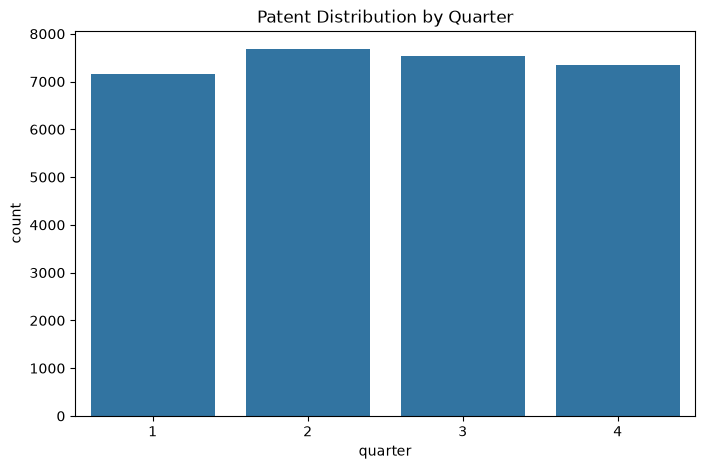

In [109]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='quarter'
)

plt.title('Patent Distribution by Quarter')

plt.show()

Keyword Score Distribution

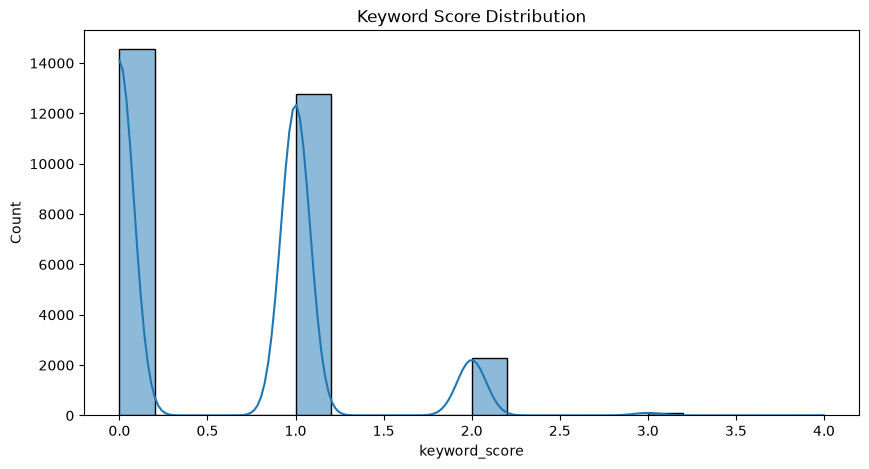

In [110]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['keyword_score'],
    bins=20,
    kde=True
)

plt.title('Keyword Score Distribution')

plt.show()

Target Variable Distribution

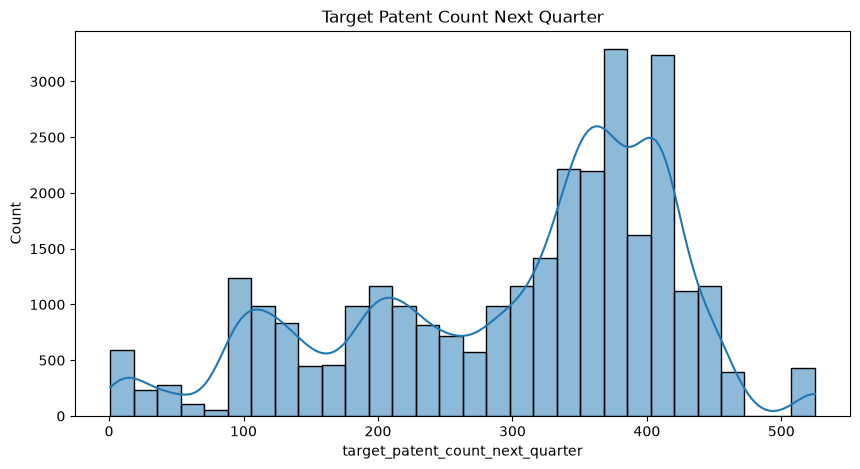

In [111]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['target_patent_count_next_quarter'],
    bins=30,
    kde=True
)

plt.title('Target Patent Count Next Quarter')

plt.show()

Boxplot for Outliers

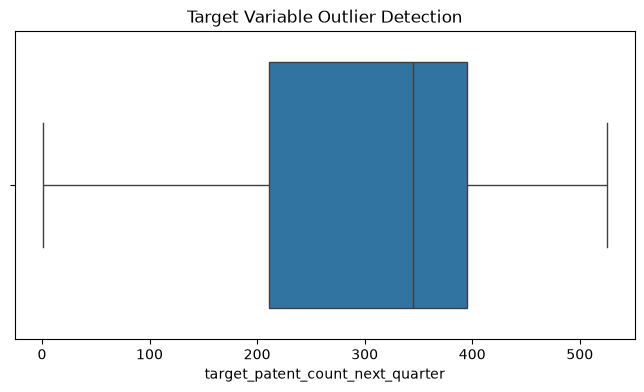

In [112]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['target_patent_count_next_quarter']
)

plt.title('Target Variable Outlier Detection')

plt.show()

Technology Trend Analysis
AI/ML Patents

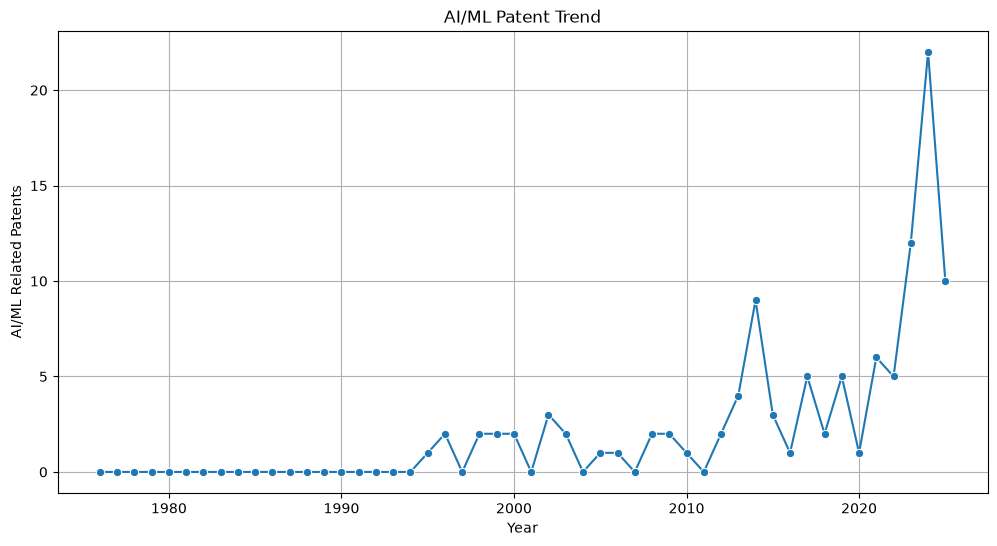

In [113]:
ai_trend = df.groupby('year')['kw_ai_ml'].sum()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=ai_trend.index,
    y=ai_trend.values,
    marker='o'
)

plt.title('AI/ML Patent Trend')

plt.xlabel('Year')
plt.ylabel('AI/ML Related Patents')

plt.grid(True)

plt.show()

5G Patent Trend

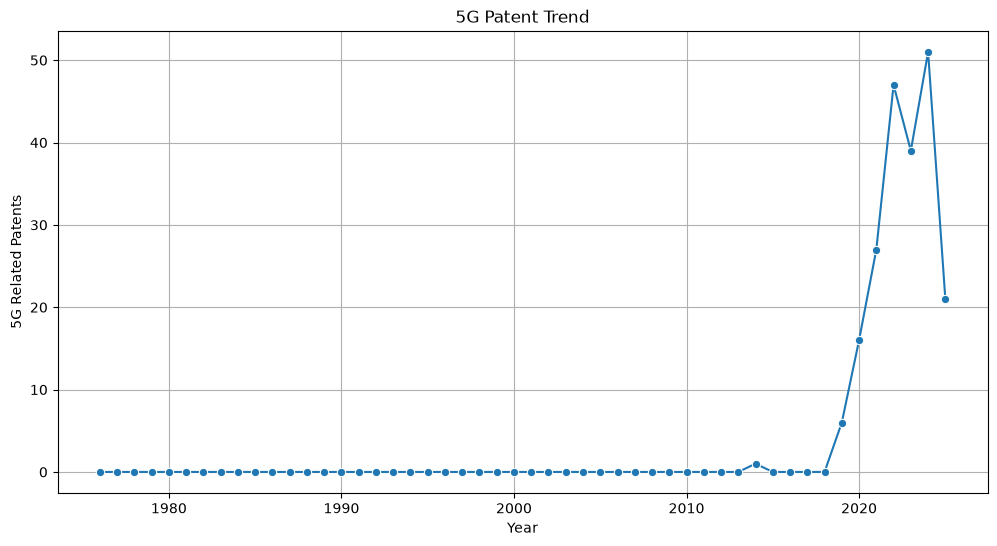

In [114]:
g5_trend = df.groupby('year')['kw_5g'].sum()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=g5_trend.index,
    y=g5_trend.values,
    marker='o'
)

plt.title('5G Patent Trend')

plt.xlabel('Year')
plt.ylabel('5G Related Patents')

plt.grid(True)

plt.show()

Correlation Analysis: 

Select numercial columns:

In [115]:
numeric_df = df.select_dtypes(include=['int64','float64'])

Correlation matrix:


In [116]:
corr_matrix = numeric_df.corr()

Heatmap:

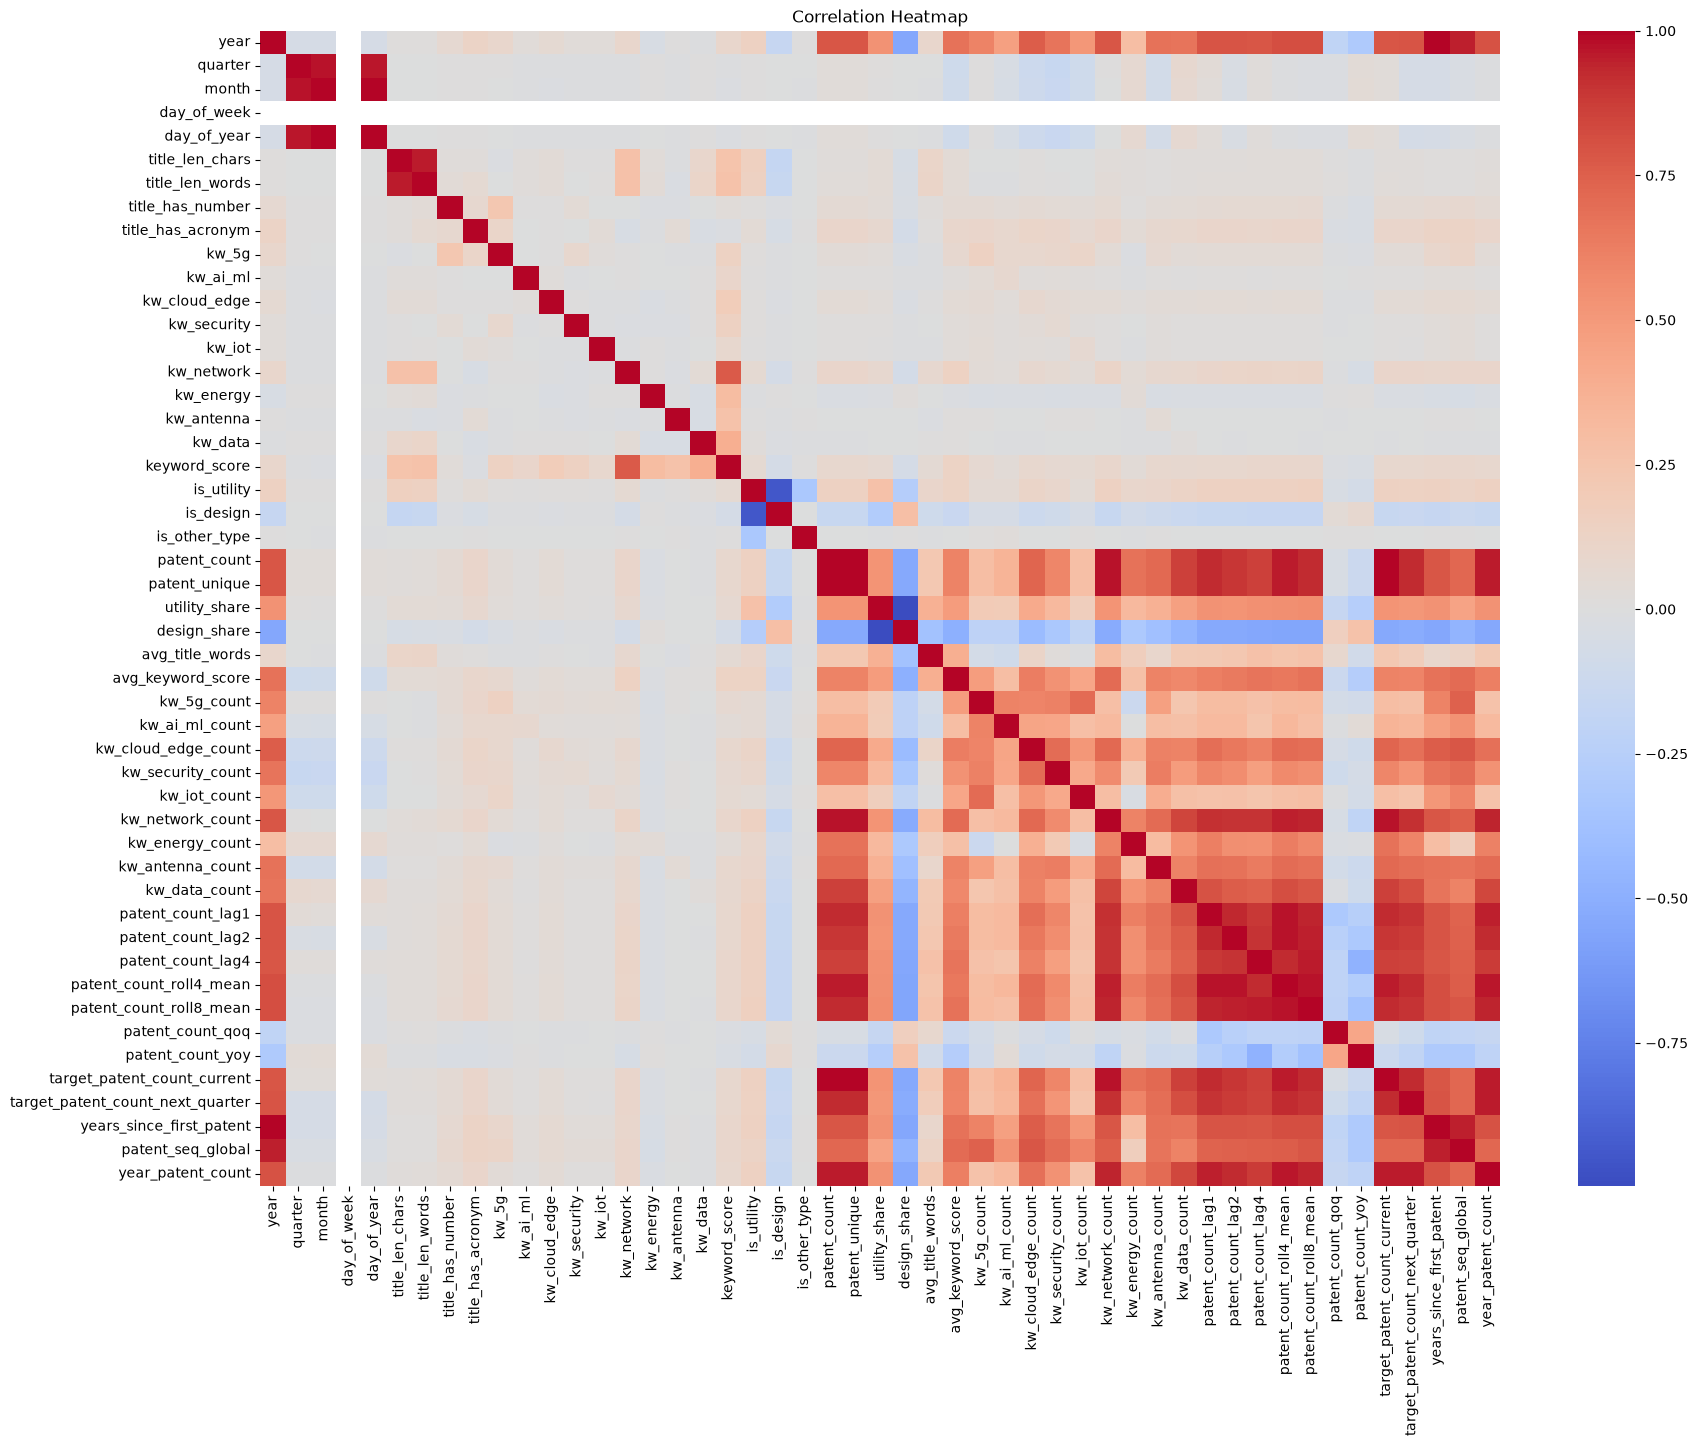

In [117]:
plt.figure(figsize=(20,15))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

Most Important Step

Find features most correlated with the target:

In [118]:
target_corr = corr_matrix['target_patent_count_next_quarter'] \
                .sort_values(ascending=False)

print(target_corr.head(15))

target_patent_count_next_quarter    1.000000
year_patent_count                   0.953959
patent_count                        0.929149
target_patent_count_current         0.929149
patent_unique                       0.929149
patent_count_roll4_mean             0.922757
kw_network_count                    0.907474
patent_count_lag1                   0.900422
patent_count_roll8_mean             0.899437
patent_count_lag2                   0.881407
patent_count_lag4                   0.853967
kw_data_count                       0.818067
year                                0.797162
years_since_first_patent            0.797162
patent_seq_global                   0.722348
Name: target_patent_count_next_quarter, dtype: float64


In [119]:
df['target_patent_count_next_quarter'].isnull().sum()

df['patent_type'].value_counts()

df['tech_era'].value_counts()

target_corr.head(15)

target_patent_count_next_quarter    1.000000
year_patent_count                   0.953959
patent_count                        0.929149
target_patent_count_current         0.929149
patent_unique                       0.929149
patent_count_roll4_mean             0.922757
kw_network_count                    0.907474
patent_count_lag1                   0.900422
patent_count_roll8_mean             0.899437
patent_count_lag2                   0.881407
patent_count_lag4                   0.853967
kw_data_count                       0.818067
year                                0.797162
years_since_first_patent            0.797162
patent_seq_global                   0.722348
Name: target_patent_count_next_quarter, dtype: float64

Some variables may cause data leakage because they are almost direct representations of the current patent count . like target_patent_count_current, patent_count, patent_unique. its better to avoid variables that directly reveal the current target state.

Feature Selection 

lets use a balanced set of historical and technology-related features:

In [120]:
features = [
    'year',
    'quarter',
    'title_len_words',
    'keyword_score',
    'kw_ai_ml',
    'kw_5g',
    'kw_cloud_edge',
    'kw_security',
    'kw_iot',
    'kw_network',
    'patent_count_lag1',
    'patent_count_lag2',
    'patent_count_lag4',
    'patent_count_roll4_mean',
    'patent_count_roll8_mean',
    'patent_count_qoq',
    'patent_count_yoy'
]

In [121]:
target = 'target_patent_count_next_quarter'

One - Hot Encoding

we can also include categorical vraibles: 
1. patent_type
2. tech_era


Perform encoding: 

In [122]:
df_encoded = pd.get_dummies(
    df,
    columns=['patent_type','tech_era'],
    drop_first=True
)

check generated columns:

In [123]:
[c for c in df_encoded.columns if 'patent_type' in c or 'tech_era' in c]

['patent_type_reissue',
 'patent_type_utility',
 'tech_era_legacy_pre_1990',
 'tech_era_mobile_2000s',
 'tech_era_modern_2020s',
 'tech_era_smartphone_2010s']

Add them to features:

In [124]:
encoded_cols = [
    col for col in df_encoded.columns
    if ('patent_type_' in col) or ('tech_era_' in col)
]

features.extend(encoded_cols)

Train - Test Split

In [125]:
from sklearn.model_selection import train_test_split

X = df_encoded[features]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(23768, 23)
(5942, 23)


Feature Scaling

important for Ridge and Lasso

In [126]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Linear Regression

In [127]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MSE:", lr_mse)
print("R2 :", lr_r2)

Linear Regression
MSE: 1586.6041291821762
R2 : 0.885114051325719


Ridge Regression

In [128]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("MSE:", ridge_mse)
print("R2 :", ridge_r2)

Ridge Regression
MSE: 1586.6304050833492
R2 : 0.8851121486886477


Lasso Regression

In [129]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Regression")
print("MSE:", lasso_mse)
print("R2 :", lasso_r2)

Lasso Regression
MSE: 1586.6762534629088
R2 : 0.8851088288091113


Comparison Table

In [130]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MSE': [
        lr_mse,
        ridge_mse,
        lasso_mse
    ],
    'R2 Score': [
        lr_r2,
        ridge_r2,
        lasso_r2
    ]
})

print(results)

               Model          MSE  R2 Score
0  Linear Regression  1586.604129  0.885114
1   Ridge Regression  1586.630405  0.885112
2   Lasso Regression  1586.676253  0.885109


Feature Importance 

In [131]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coef_df.head(30))

                      Feature  Coefficient
13    patent_count_roll4_mean    52.253363
10          patent_count_lag1    31.937579
22  tech_era_smartphone_2010s    21.527154
0                        year    14.647277
12          patent_count_lag4    12.128287
15           patent_count_qoq    10.604961
21      tech_era_modern_2020s     9.770061
16           patent_count_yoy     4.922798
14    patent_count_roll8_mean     4.254206
3               keyword_score     0.265910
4                    kw_ai_ml     0.214744
6               kw_cloud_edge     0.062835
17        patent_type_reissue    -0.027354
5                       kw_5g    -0.104520
8                      kw_iot    -0.188277
18        patent_type_utility    -0.232611
9                  kw_network    -0.386249
2             title_len_words    -0.532253
7                 kw_security    -0.634593
20      tech_era_mobile_2000s    -0.934118
19   tech_era_legacy_pre_1990    -4.271992
1                     quarter    -7.611992
11         

In [132]:
#model results from the linear regression model can be saved to a CSV file for further analysis or reporting
results.to_csv('model_results.csv', index=False)

Interpretation
1. R² = 0.885 means the models explain approximately 88.5% of the variation in Ericsson's future patent activity.
2. This is a strong predictive performance for a real-world forecasting problem.
3. The MSE values are relatively low and nearly identical across all models.
4. Since Ridge and Lasso do not significantly improve performance, the dataset does not appear to suffer from severe multicollinearity or overfitting.
5. Historical patent activity variables such as lag features and rolling averages are strong predictors of future patent counts.

In [133]:
# Select one sample from test data
sample = X_test.iloc[[0]]

# Scale it
sample_scaled = scaler.transform(sample)

# Predict
prediction = lr.predict(sample_scaled)

print("Predicted Patent Count:", prediction[0])
print("Actual Patent Count:", y_test.iloc[0])

Predicted Patent Count: 221.14995281388298
Actual Patent Count: 230.0


In [134]:
features = [
    'year',
    'quarter',
    'title_len_words',
    'keyword_score',
    'kw_ai_ml',
    'kw_5g',
    'kw_cloud_edge',
    'kw_security',
    'kw_iot',
    'kw_network',
    'patent_count_lag1',
    'patent_count_lag2',
    'patent_count_lag4',
    'patent_count_roll4_mean',
    'patent_count_roll8_mean',
    'patent_count_qoq',
    'patent_count_yoy'
]

In [135]:
import pandas as pd

new_data = pd.DataFrame({
    'year': [2026],
    'quarter': [2],
    'title_len_words': [8],
    'keyword_score': [4],
    'kw_ai_ml': [1],
    'kw_5g': [1],
    'kw_cloud_edge': [0],
    'kw_security': [0],
    'kw_iot': [1],
    'kw_network': [1],
    'patent_count_lag1': [120],
    'patent_count_lag2': [115],
    'patent_count_lag4': [100],
    'patent_count_roll4_mean': [110],
    'patent_count_roll8_mean': [105],
    'patent_count_qoq': [0.08],
    'patent_count_yoy': [0.12]
})

In [137]:
sample = X.iloc[[0]]

sample_scaled = scaler.transform(sample)

prediction = lr.predict(sample_scaled)

print("Prediction:", prediction[0])
print("Actual:", y.iloc[0])

Prediction: 223.3755979345175
Actual: 5.0


In [138]:
print(X.columns.tolist())
print("Number of features:", len(X.columns))

['year', 'quarter', 'title_len_words', 'keyword_score', 'kw_ai_ml', 'kw_5g', 'kw_cloud_edge', 'kw_security', 'kw_iot', 'kw_network', 'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4', 'patent_count_roll4_mean', 'patent_count_roll8_mean', 'patent_count_qoq', 'patent_count_yoy', 'patent_type_reissue', 'patent_type_utility', 'tech_era_legacy_pre_1990', 'tech_era_mobile_2000s', 'tech_era_modern_2020s', 'tech_era_smartphone_2010s']
Number of features: 23


In [140]:
new_data = pd.DataFrame(
    0,
    index=[0],
    columns=X.columns
)

In [139]:
new_data['year'] = 2026
new_data['quarter'] = 2
new_data['title_len_words'] = 8
new_data['keyword_score'] = 4
new_data['kw_ai_ml'] = 1
new_data['kw_5g'] = 1
new_data['kw_network'] = 1

new_data['patent_count_lag1'] = 120
new_data['patent_count_lag2'] = 115
new_data['patent_count_lag4'] = 100
new_data['patent_count_roll4_mean'] = 110
new_data['patent_count_roll8_mean'] = 105
new_data['patent_count_qoq'] = 0.08
new_data['patent_count_yoy'] = 0.12

# Example encoded categories
new_data['patent_type_utility'] = 1
new_data['tech_era_modern_2020s'] = 1

In [141]:
new_data_scaled = scaler.transform(new_data)

prediction = lr.predict(new_data_scaled)

print("Predicted Next Quarter Patent Count:", prediction[0])

Predicted Next Quarter Patent Count: -3261.385977975874


In [142]:
latest_record = X.iloc[[-1]]

latest_scaled = scaler.transform(latest_record)

prediction = lr.predict(latest_scaled)

print("Forecasted Next Quarter Patent Count:", prediction[0])
print("Actual Next Quarter Patent Count:", y.iloc[-1])

Forecasted Next Quarter Patent Count: 381.9249535938008
Actual Next Quarter Patent Count: 408.0


In [143]:
latest_features = df_encoded[features].tail(1)

latest_scaled = scaler.transform(latest_features)

prediction = lr.predict(latest_scaled)

print(prediction)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- patent_type_reissue
- patent_type_utility
- tech_era_legacy_pre_1990
- tech_era_mobile_2000s
- tech_era_modern_2020s
- ...


In [144]:
print(X.shape)
print(X.columns.tolist())

(29710, 23)
['year', 'quarter', 'title_len_words', 'keyword_score', 'kw_ai_ml', 'kw_5g', 'kw_cloud_edge', 'kw_security', 'kw_iot', 'kw_network', 'patent_count_lag1', 'patent_count_lag2', 'patent_count_lag4', 'patent_count_roll4_mean', 'patent_count_roll8_mean', 'patent_count_qoq', 'patent_count_yoy', 'patent_type_reissue', 'patent_type_utility', 'tech_era_legacy_pre_1990', 'tech_era_mobile_2000s', 'tech_era_modern_2020s', 'tech_era_smartphone_2010s']


In [145]:
import pandas as pd

new_data = pd.DataFrame({
    'year': [2026],
    'quarter': [2],
    'title_len_words': [8],
    'keyword_score': [4],
    'kw_ai_ml': [1],
    'kw_5g': [1],
    'kw_cloud_edge': [0],
    'kw_security': [0],
    'kw_iot': [1],
    'kw_network': [1],
    'patent_count_lag1': [120],
    'patent_count_lag2': [115],
    'patent_count_lag4': [100],
    'patent_count_roll4_mean': [110],
    'patent_count_roll8_mean': [105],
    'patent_count_qoq': [0.08],
    'patent_count_yoy': [0.12],
    
    'patent_type_reissue': [0],
    'patent_type_utility': [1],

    'tech_era_legacy_pre_1990': [0],
    'tech_era_mobile_2000s': [0],
    'tech_era_modern_2020s': [1],
    'tech_era_smartphone_2010s': [0]
})

In [146]:
print(list(new_data.columns) == list(X.columns))

True


In [147]:
new_data_scaled = scaler.transform(new_data)

prediction = lr.predict(new_data_scaled)

print("Predicted Patent Count for Next Quarter:")
print(round(prediction[0], 2))

Predicted Patent Count for Next Quarter:
189.41


In [148]:
latest_input = X.tail(1)

latest_scaled = scaler.transform(latest_input)

future_prediction = lr.predict(latest_scaled)

print("Forecasted Patent Count:", round(future_prediction[0], 2))

Forecasted Patent Count: 381.92


In [149]:
sample = X_test.iloc[[10]]

actual = y_test.iloc[10]

sample_scaled = scaler.transform(sample)

predicted = lr.predict(sample_scaled)

print("Actual Value    :", actual)
print("Predicted Value :", round(predicted[0], 2))

Actual Value    : 126.0
Predicted Value : 174.2


In [150]:
for i in range(10):
    sample = X_test.iloc[[i]]

    actual = y_test.iloc[i]

    sample_scaled = scaler.transform(sample)

    pred = lr.predict(sample_scaled)

    print(
        f"Actual: {actual:.0f} | Predicted: {pred[0]:.2f}"
    )

Actual: 230 | Predicted: 221.15
Actual: 230 | Predicted: 221.10
Actual: 304 | Predicted: 291.84
Actual: 410 | Predicted: 363.13
Actual: 418 | Predicted: 428.86
Actual: 418 | Predicted: 428.99
Actual: 207 | Predicted: 118.82
Actual: 355 | Predicted: 364.06
Actual: 322 | Predicted: 342.00
Actual: 334 | Predicted: 365.06


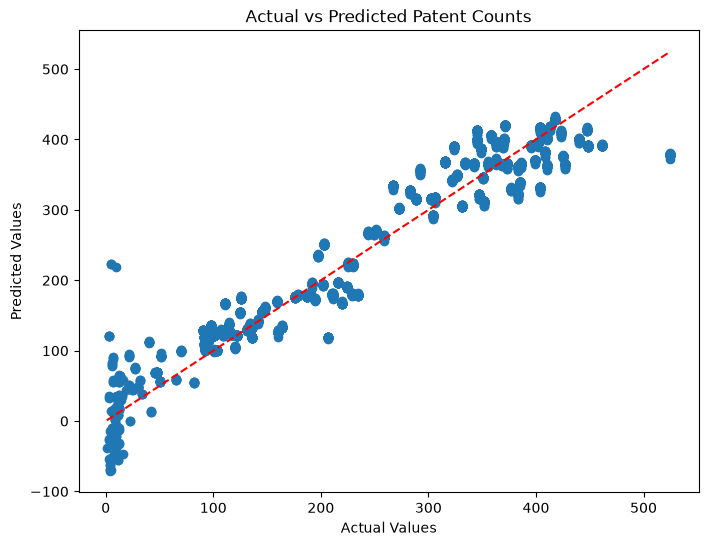

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Patent Counts")

plt.show()

In [152]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    y_pred_lr
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 30.74364770777471


In [153]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_lr
})

comparison['Error'] = abs(
    comparison['Actual'] - comparison['Predicted']
)

comparison.sort_values(
    by='Error'
).head(10)

,Actual,Predicted,Error
1175,176.0,175.988722,0.011278
2433,122.0,122.013942,0.013942
1924,142.0,141.975821,0.024179
5854,142.0,141.975821,0.024179
3020,142.0,141.964480,0.035520
1800,225.0,224.957994,0.042006
1797,179.0,179.053574,0.053574
2073,179.0,178.932186,0.067814
1964,179.0,179.090053,0.090053
3123,142.0,142.097210,0.097210


In [154]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_lr)
print(mae)

30.74364770777471


In [155]:
from sklearn.ensemble import RandomForestRegressor

In [156]:
from xgboost import XGBRegressor

ModuleNotFoundError: No module named 'xgboost'